# Instalaciones

In [1]:
# %pip install jenkspy
# %pip install scikit-posthocs
# %pip install jinja2



## Importaciones

In [51]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import spearmanr
import jenkspy
import scikit_posthocs as sp
from scipy.stats import kruskal
import scikit_posthocs as sp
from scipy.stats import mannwhitneyu
import statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestRegressor


## Carga del Dataset

In [3]:
df = pd.read_csv("../Data/data_cleaning_2026_27_04.csv", decimal=",")

In [4]:
df.columns

Index(['id', 'motivo_ausencia', 'mes_ausencia', 'dia_semana', 'estaciones',
       'gasto_transporte', 'distancia_casa_trabajo', 'tiempo_servicio', 'edad',
       'carga_trabajo_diaria', 'cumplimiento_objetivo', 'falta_disciplinaria',
       'educacion', 'hijos', 'bebedor_social', 'fumador_social', 'mascota',
       'peso', 'estatura', 'indice_masa_corporal', 'horas_ausentismo',
       'indicador_enfermedad', 'motivo_ausencia_mapeado',
       'mes_ausencia_mapeado', 'educacion_mapeada'],
      dtype='str')

## Transformación de datos

In [5]:
df_clean = df.loc[:, ~df.columns.isin(['mascota', 'peso', 'estatura'])]

In [6]:
df_clean = df_clean[df_clean['horas_ausentismo'] > 0]
df_clean.info()

<class 'pandas.DataFrame'>
Index: 757 entries, 0 to 805
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       757 non-null    int64  
 1   motivo_ausencia          757 non-null    int64  
 2   mes_ausencia             757 non-null    float64
 3   dia_semana               757 non-null    str    
 4   estaciones               757 non-null    str    
 5   gasto_transporte         757 non-null    int64  
 6   distancia_casa_trabajo   757 non-null    int64  
 7   tiempo_servicio          757 non-null    int64  
 8   edad                     757 non-null    int64  
 9   carga_trabajo_diaria     757 non-null    float64
 10  cumplimiento_objetivo    757 non-null    int64  
 11  falta_disciplinaria      757 non-null    int64  
 12  educacion                757 non-null    int64  
 13  hijos                    757 non-null    int64  
 14  bebedor_social           757 non-null    i

# Análisis descriptiva inicial

### Variables clave para responder a la pregunta:
#### - bebedor_social (0/1)
#### - fumador_social (0/1)
#### - falta_disciplinaria (0/1 o conteo)
#### - horas_ausentismo (variable dependiente)



===== Distribución de horas de absentismo según bebedor_social =====
                count      mean        std  min  25%  50%  75%    max
bebedor_social                                                       
0               348.0  6.077586  12.464232  0.0  2.0  3.0  8.0  120.0
1               458.0  8.580786  16.074329  0.0  2.0  4.0  8.0  120.0


===== Distribución de horas de absentismo según fumador_social =====
                count      mean        std  min  25%  50%  75%    max
fumador_social                                                       
0               749.0  7.527370  14.923991  0.0  2.0  3.0  8.0  120.0
1                57.0  7.140351  10.875002  0.0  2.0  4.0  8.0   64.0


===== Distribución de horas de absentismo según falta_disciplinaria =====
                     count      mean        std  min  25%  50%  75%    max
falta_disciplinaria                                                       
0                    762.0  7.933071  14.973107  0.0  2.0  4.0  8.0  120

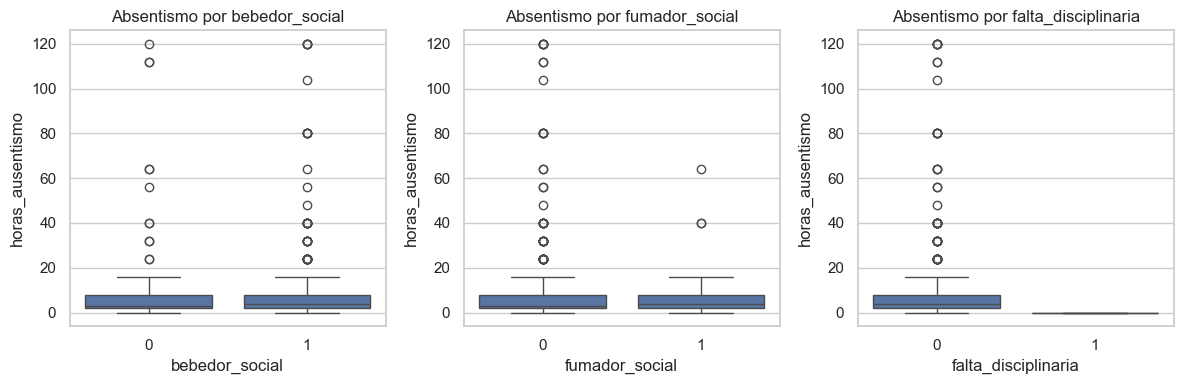

In [42]:
# 3. Análisis descriptivo
# ============================================================

# --- Estadísticos descriptivos por grupo ---
variables_estudio = ["bebedor_social", "fumador_social", "falta_disciplinaria"]

for var in variables_estudio:
    print(f"\n\n===== Distribución de horas de absentismo según {var} =====")
    print(df.groupby(var)["horas_ausentismo"].describe())

# --- Boxplots comparativos ---
plt.figure(figsize=(12,4))
for i, var in enumerate(variables_estudio, 1):
    plt.subplot(1,3,i)
    sns.boxplot(data=df, x=var, y="horas_ausentismo")
    plt.title(f"Absentismo por {var}")
plt.tight_layout()
plt.show()


## Pruebas Estadísticas no paramétricas
## Mann-Whitney U - **variables binarias**

In [46]:
# 4. Pruebas estadísticas no paramétricas
# ============================================================

# --- Mann–Whitney U para variables binarias ---
for var in variables_estudio:
    grupo1 = df[df[var] == 1]["horas_ausentismo"]
    grupo0 = df[df[var] == 0]["horas_ausentismo"]

    stat, p = stats.mannwhitneyu(grupo1, grupo0, alternative="two-sided")
    print(f"\nMann–Whitney U para {var}: U={stat:.2f}, p={p:.5f}")

# --- Correlación Spearman si falta_disciplinaria es numérica ---
if df["falta_disciplinaria"].nunique() > 2:
    rho, p = spearmanr(df["falta_disciplinaria"], df["horas_ausentismo"])
    print(f"\nCorrelación Spearman (falta_disciplinaria vs horas_ausentismo): rho={rho:.3f}, p={p:.5f}")




Mann–Whitney U para bebedor_social: U=88835.00, p=0.00445

Mann–Whitney U para fumador_social: U=21417.00, p=0.96643

Mann–Whitney U para falta_disciplinaria: U=110.00, p=0.00000


## Modelo Multivariable
## Regresión OLS

In [49]:
# 5. Modelo multivariable (Regresión OLS)
# ============================================================

# Fórmula del modelo:
# Incluimos variables de control relevantes para evitar sesgos:
# edad, carga_trabajo_diaria, hijos, tiempo_servicio, motivo_ausencia_mapeado

modelo = smf.ols(
    "horas_ausentismo ~ bebedor_social + fumador_social + falta_disciplinaria + edad + carga_trabajo_diaria + hijos + tiempo_servicio + C(motivo_ausencia_mapeado)",
    data=df
).fit()

print("\n\n===== Resultados del modelo OLS =====")
print(modelo.summary())




===== Resultados del modelo OLS =====
                            OLS Regression Results                            
Dep. Variable:       horas_ausentismo   R-squared:                       0.209
Model:                            OLS   Adj. R-squared:                  0.174
Method:                 Least Squares   F-statistic:                     5.973
Date:                Mon, 04 May 2026   Prob (F-statistic):           2.75e-21
Time:                        23:21:48   Log-Likelihood:                -3039.1
No. Observations:                 758   AIC:                             6144.
Df Residuals:                     725   BIC:                             6297.
Df Model:                          32                                         
Covariance Type:            nonrobust                                         
                                                                  coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------

## Ramdom Forest



===== Importancia de variables (Random Forest) =====
carga_trabajo_diaria    0.629279
edad                    0.174328
tiempo_servicio         0.090548
hijos                   0.067991
bebedor_social          0.016354
falta_disciplinaria     0.015227
fumador_social          0.006273
dtype: float64


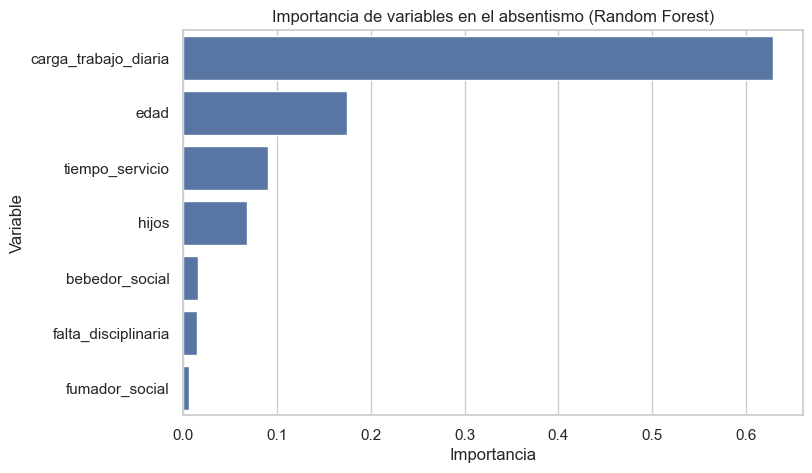

In [52]:
# 6. Importancia de variables (Random Forest)
# ============================================================

# Selección de variables numéricas para el modelo
X = df[["bebedor_social", "fumador_social", "falta_disciplinaria",
        "edad", "carga_trabajo_diaria", "hijos", "tiempo_servicio"]]

y = df["horas_ausentismo"]

# Entrenamiento del modelo
rf = RandomForestRegressor(random_state=42)
rf.fit(X, y)

# Importancia de variables
importancias = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("\n\n===== Importancia de variables (Random Forest) =====")
print(importancias)

# --- Visualización ---
plt.figure(figsize=(8,5))
sns.barplot(x=importancias.values, y=importancias.index)
plt.title("Importancia de variables en el absentismo (Random Forest)")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()


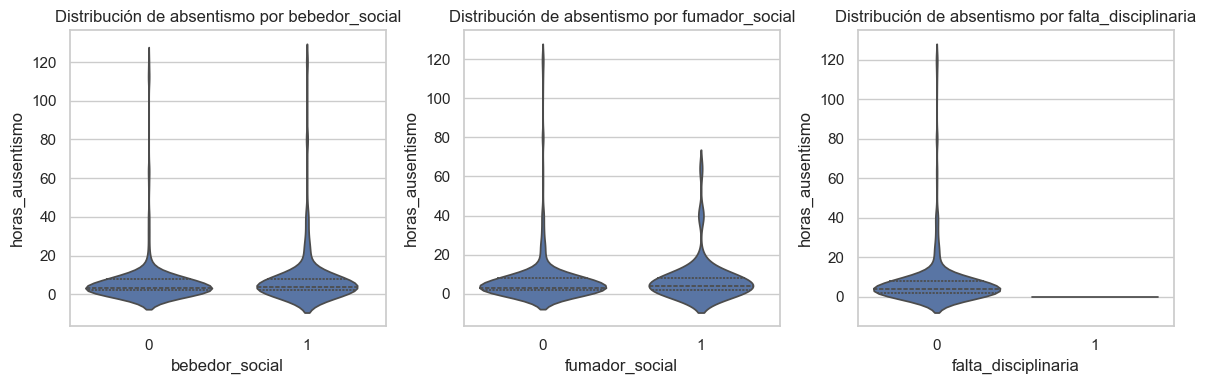

In [53]:
# 7. Visualización adicional: violines
# ============================================================

plt.figure(figsize=(12,4))
for i, var in enumerate(variables_estudio, 1):
    plt.subplot(1,3,i)
    sns.violinplot(data=df, x=var, y="horas_ausentismo", inner="quartile")
    plt.title(f"Distribución de absentismo por {var}")
plt.tight_layout()
plt.show()
